In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip install -q datasets PyYAML scikit-learn

In [3]:
from pathlib import Path

import torch


PROJECT_ROOT = Path(
    "/content/drive/MyDrive/ATML/PA1"
)

REPO_ROOT = Path(
    "/content/drive/MyDrive/ATML/PA1-repo"
)

TASK2_WORK_ROOT = (
    PROJECT_ROOT / "task2"
)

TASK2_REPO_ROOT = (
    REPO_ROOT / "task2"
)

PACS_ROOT = (
    PROJECT_ROOT / "datasets/PACS"
)

CHECKPOINT_DIRECTORY = (
    TASK2_WORK_ROOT / "checkpoints"
)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

Device: cuda


In [4]:
checkpoint_paths = {
    "source_only": (
        CHECKPOINT_DIRECTORY
        / "source_only_best.pt"
    ),
    "dan": (
        CHECKPOINT_DIRECTORY
        / "dan_best.pt"
    ),
    "dann": (
        CHECKPOINT_DIRECTORY
        / "dann_best.pt"
    ),
    "cdan": (
        CHECKPOINT_DIRECTORY
        / "cdan_best.pt"
    ),
}

all_checkpoints_exist = True

for method_name, checkpoint_path in (
    checkpoint_paths.items()
):
    exists = checkpoint_path.exists()

    print(
        f"{method_name:12s}",
        "| exists:",
        exists,
        "|",
        checkpoint_path,
    )

    all_checkpoints_exist &= exists

if not all_checkpoints_exist:
    raise FileNotFoundError(
        "One or more selected checkpoints "
        "are missing."
    )

print()
print(
    "All selected checkpoints are fixed."
)
print(
    "No further training or tuning is "
    "allowed after target evaluation."
)

source_only  | exists: True | /content/drive/MyDrive/ATML/PA1/task2/checkpoints/source_only_best.pt
dan          | exists: True | /content/drive/MyDrive/ATML/PA1/task2/checkpoints/dan_best.pt
dann         | exists: True | /content/drive/MyDrive/ATML/PA1/task2/checkpoints/dann_best.pt
cdan         | exists: True | /content/drive/MyDrive/ATML/PA1/task2/checkpoints/cdan_best.pt

All selected checkpoints are fixed.
No further training or tuning is allowed after target evaluation.


In [5]:
%cd /content/drive/MyDrive/ATML/PA1-repo

import inspect

import shared.pacs as pacs_module

from shared.pacs_loaders import (
    build_pacs_datasets,
)

sample_checkpoint = torch.load(
    checkpoint_paths["source_only"],
    map_location="cpu",
    weights_only=False,
)

print("Available PACS utilities:")

for name in dir(pacs_module):
    if (
        "Dataset" in name
        or "transform" in name.lower()
    ):
        print(" -", name)

print()
print(
    "build_pacs_datasets signature:"
)
print(
    inspect.signature(
        build_pacs_datasets
    )
)

print()
print("Checkpoint keys:")
print(
    list(sample_checkpoint.keys())
)

/content/drive/.shortcut-targets-by-id/1tphHcVs5KfBbfa3Y2U6Gt0Lo7AWXysa4/ATML/PA1-repo
Available PACS utilities:
 - Dataset
 - PACSLabeledDataset
 - PACSUnlabeledTargetDataset
 - build_pacs_evaluation_transform
 - build_pacs_train_transform
 - transforms

build_pacs_datasets signature:
(dataset, protocol)

Checkpoint keys:
['epoch', 'selection_metric', 'selection_score', 'model_state_dict', 'optimizer_state_dict', 'additional_model_state_dicts', 'extra_state']


In [6]:
from datasets import load_from_disk

from shared.pacs import (
    PACSLabeledDataset,
    build_pacs_evaluation_transform,
)

from shared.pacs_protocol import (
    load_pacs_protocol,
)


pacs_dataset = load_from_disk(
    str(PACS_ROOT)
)

PACS_SPLIT_PATH = (
    REPO_ROOT
    / "shared/splits/"
    "pacs_sketch_seed6304.json"
)

pacs_protocol = load_pacs_protocol(
    PACS_SPLIT_PATH
)

print(
    "PACSLabeledDataset signature:"
)
print(
    inspect.signature(
        PACSLabeledDataset
    )
)

print()
print(
    "Evaluation-transform signature:"
)
print(
    inspect.signature(
        build_pacs_evaluation_transform
    )
)

print()
print("Protocol keys:")

for key, value in (
    pacs_protocol.items()
):
    if isinstance(value, dict):
        print(
            key,
            "| dictionary keys:",
            list(value.keys()),
        )
    elif isinstance(value, list):
        print(
            key,
            "| list length:",
            len(value),
        )
    else:
        print(
            key,
            "|",
            value,
        )

PACSLabeledDataset signature:
(dataset, indices, transform, domain_name)

Evaluation-transform signature:
()

Protocol keys:
seed | 6304
validation_fraction | 0.2
source_domains | list length: 3
target_domain | sketch
class_names | list length: 7
source_splits | dictionary keys: ['photo', 'art_painting', 'cartoon']
target_adaptation_indices | list length: 3929


In [7]:
from torch.utils.data import DataLoader


target_evaluation_dataset = (
    PACSLabeledDataset(
        dataset=pacs_dataset,
        indices=(
            pacs_protocol[
                "target_adaptation_indices"
            ]
        ),
        transform=(
            build_pacs_evaluation_transform()
        ),
        domain_name=(
            pacs_protocol[
                "target_domain"
            ]
        ),
    )
)

target_evaluation_loader = DataLoader(
    target_evaluation_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=(
        DEVICE.type == "cuda"
    ),
)

CLASS_NAMES = (
    pacs_protocol["class_names"]
)

print(
    "Target domain:",
    pacs_protocol["target_domain"],
)

print(
    "Target evaluation samples:",
    len(target_evaluation_dataset),
)

print(
    "Classes:",
    CLASS_NAMES,
)

Target domain: sketch
Target evaluation samples: 3929
Classes: ['dog', 'elephant', 'giraffe', 'guitar', 'horse', 'house', 'person']


In [8]:
import numpy as np

import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    f1_score,
)

from tqdm.auto import tqdm

from task2.models.classifier_head import (
    PACSClassifier,
)


target_outputs = {}

for method_name, checkpoint_path in (
    checkpoint_paths.items()
):
    print()
    print("=" * 70)
    print(
        "Evaluating:",
        method_name,
    )
    print("=" * 70)

    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False,
    )

    model = PACSClassifier(
        number_of_classes=7
    ).to(DEVICE)

    model.load_state_dict(
        checkpoint["model_state_dict"],
        strict=True,
    )

    model.eval()

    true_labels = []
    predicted_labels = []

    with torch.inference_mode():
        for batch in tqdm(
            target_evaluation_loader,
            desc=(
                f"{method_name}: Sketch"
            ),
        ):
            images = batch["image"].to(
                DEVICE,
                non_blocking=True,
            )

            labels = batch["label"]

            logits = model(images)

            predictions = (
                logits.argmax(dim=1)
                .cpu()
            )

            true_labels.extend(
                labels.cpu().tolist()
            )

            predicted_labels.extend(
                predictions.tolist()
            )

    true_labels = np.asarray(
        true_labels,
        dtype=np.int64,
    )

    predicted_labels = np.asarray(
        predicted_labels,
        dtype=np.int64,
    )

    accuracy = accuracy_score(
        true_labels,
        predicted_labels,
    )

    macro_f1 = f1_score(
        true_labels,
        predicted_labels,
        average="macro",
        zero_division=0,
    )

    target_outputs[method_name] = {
        "true_labels": true_labels,
        "predicted_labels": (
            predicted_labels
        ),
        "accuracy": float(accuracy),
        "macro_f1": float(macro_f1),
        "selected_epoch": int(
            checkpoint["epoch"]
        ),
        "source_selection_score": float(
            checkpoint["selection_score"]
        ),
    }

    print(
        "Target accuracy:",
        accuracy,
    )

    print(
        "Target macro-F1:",
        macro_f1,
    )

    del model

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()


Evaluating: source_only
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 191MB/s]


source_only: Sketch:   0%|          | 0/62 [00:00<?, ?it/s]

Target accuracy: 0.6482565538304912
Target macro-F1: 0.6240024389156957

Evaluating: dan


dan: Sketch:   0%|          | 0/62 [00:00<?, ?it/s]

...

dann: Sketch:   0%|          | 0/62 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b9d24169580>
Traceback (most recent call last):
Exception ignored in:   File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
<function _MultiProcessingDataLoaderIter.__del__ at 0x7b9d24169580>    
self._shutdown_workers()Traceback (most recent call last):

  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
        if w.is_alive():self._shutdown_workers()

  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
        if w.is_alive():assert self._parent_pid == os.getpid(), 'can only test a child process'

AssertionError: can only test a child process  File "/usr/lib/p

Target accuracy: 0.04224993637057776
Target macro-F1: 0.013454860210762202

Evaluating: cdan


cdan: Sketch:   0%|          | 0/62 [00:00<?, ?it/s]

Target accuracy: 0.804530414863833
Target macro-F1: 0.8118815736716278


In [9]:
target_summary_rows = []

for method_name, output in (
    target_outputs.items()
):
    target_summary_rows.append(
        {
            "method": method_name,
            "selected_epoch": (
                output["selected_epoch"]
            ),
            "source_selection_macro_f1": (
                output[
                    "source_selection_score"
                ]
            ),
            "target_accuracy": (
                output["accuracy"]
            ),
            "target_macro_f1": (
                output["macro_f1"]
            ),
            "number_of_target_samples": (
                len(
                    output["true_labels"]
                )
            ),
        }
    )

target_summary = pd.DataFrame(
    target_summary_rows
).sort_values(
    "target_macro_f1",
    ascending=False,
).reset_index(
    drop=True
)

summary_path = (
    TASK2_REPO_ROOT
    / "results/"
    "target_sketch_summary.csv"
)

target_summary.to_csv(
    summary_path,
    index=False,
)

print(
    target_summary.to_string(
        index=False
    )
)

print()
print(
    "Results saved to:",
    summary_path,
)

     method  selected_epoch  source_selection_macro_f1  target_accuracy  target_macro_f1  number_of_target_samples
       cdan              11                   0.935145         0.804530         0.811882                      3929
source_only              12                   0.936674         0.648257         0.624002                      3929
        dan               7                   0.939785         0.579791         0.550344                      3929
       dann              13                   0.951841         0.042250         0.013455                      3929

Results saved to: /content/drive/MyDrive/ATML/PA1-repo/task2/results/target_sketch_summary.csv


In [10]:
from sklearn.metrics import (
    precision_recall_fscore_support,
)


per_class_rows = []

for method_name, output in (
    target_outputs.items()
):
    precision, recall, f1, support = (
        precision_recall_fscore_support(
            output["true_labels"],
            output["predicted_labels"],
            labels=range(
                len(CLASS_NAMES)
            ),
            zero_division=0,
        )
    )

    for class_index, class_name in (
        enumerate(CLASS_NAMES)
    ):
        per_class_rows.append(
            {
                "method": method_name,
                "class_index": class_index,
                "class_name": class_name,
                "precision": float(
                    precision[class_index]
                ),
                "recall": float(
                    recall[class_index]
                ),
                "f1": float(
                    f1[class_index]
                ),
                "support": int(
                    support[class_index]
                ),
            }
        )

per_class_table = pd.DataFrame(
    per_class_rows
)

per_class_path = (
    TASK2_REPO_ROOT
    / "results/"
    "target_sketch_per_class.csv"
)

per_class_table.to_csv(
    per_class_path,
    index=False,
)

print(
    per_class_table.to_string(
        index=False
    )
)

print()
print(
    "Saved to:",
    per_class_path,
)

     method  class_index class_name  precision   recall       f1  support
source_only            0        dog   0.494881 0.563472 0.526953      772
source_only            1   elephant   0.766610 0.608108 0.678222      740
source_only            2    giraffe   0.513431 0.888446 0.650778      753
source_only            3     guitar   0.997768 0.735197 0.846591      608
source_only            4      horse   0.756452 0.574755 0.653203      816
source_only            5      house   1.000000 0.487500 0.655462       80
source_only            6     person   0.716981 0.237500 0.356808      160
        dan            0        dog   0.710526 0.314767 0.436266      772
        dan            1   elephant   0.839564 0.728378 0.780029      740
        dan            2    giraffe   0.772102 0.521912 0.622821      753
        dan            3     guitar   1.000000 0.654605 0.791252      608
        dan            4      horse   0.818476 0.618873 0.704815      816
        dan            5      house   

In [11]:
reference_labels = (
    target_outputs[
        "source_only"
    ]["true_labels"]
)

prediction_data = {
    "dataset_index": (
        pacs_protocol[
            "target_adaptation_indices"
        ]
    ),
    "true_label": reference_labels,
    "true_class": [
        CLASS_NAMES[label]
        for label in reference_labels
    ],
}

for method_name, output in (
    target_outputs.items()
):
    predictions = (
        output["predicted_labels"]
    )

    prediction_data[
        f"{method_name}_prediction"
    ] = predictions

    prediction_data[
        f"{method_name}_predicted_class"
    ] = [
        CLASS_NAMES[label]
        for label in predictions
    ]

prediction_table = pd.DataFrame(
    prediction_data
)

predictions_path = (
    TASK2_REPO_ROOT
    / "results/"
    "target_sketch_predictions.csv"
)

prediction_table.to_csv(
    predictions_path,
    index=False,
)

print(
    prediction_table.head().to_string(
        index=False
    )
)

print()
print(
    "Saved predictions:",
    predictions_path,
)

 dataset_index  true_label true_class  source_only_prediction source_only_predicted_class  dan_prediction dan_predicted_class  dann_prediction dann_predicted_class  cdan_prediction cdan_predicted_class
          6062           0        dog                       1                    elephant               5               house                6               person                6               person
          6063           0        dog                       2                     giraffe               5               house                6               person                2              giraffe
          6064           0        dog                       2                     giraffe               5               house                6               person                2              giraffe
          6065           0        dog                       1                    elephant               6              person                6               person                1            

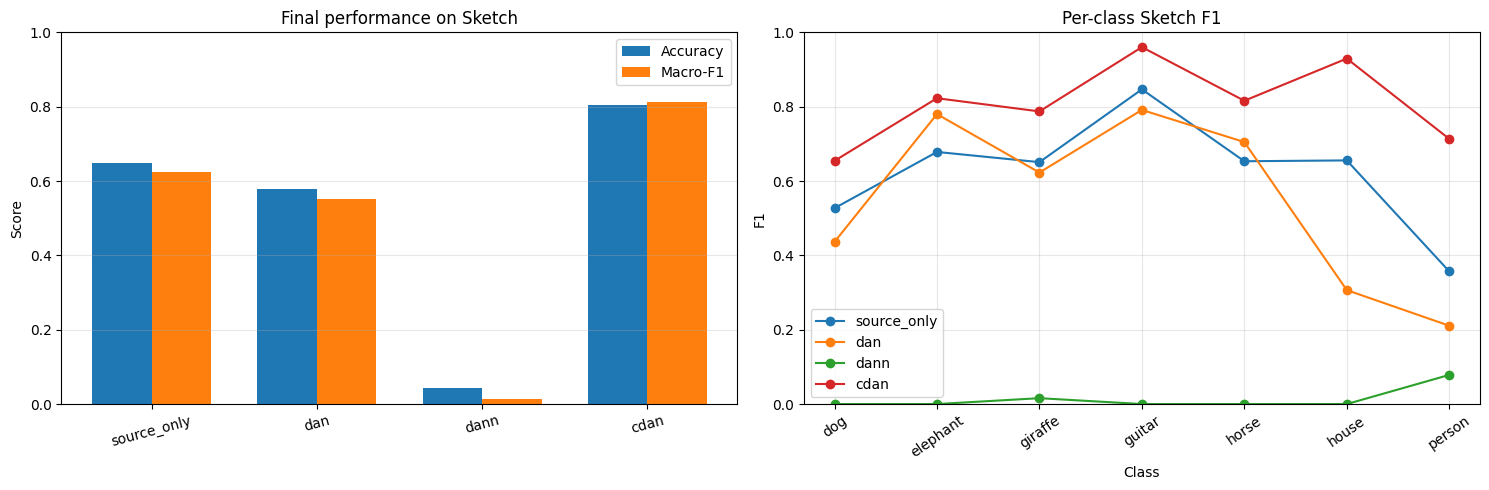

Figure saved to: /content/drive/MyDrive/ATML/PA1-repo/task2/figures/target_sketch_performance.png


In [12]:
import matplotlib.pyplot as plt


method_order = [
    "source_only",
    "dan",
    "dann",
    "cdan",
]

ordered_summary = (
    target_summary
    .set_index("method")
    .loc[method_order]
    .reset_index()
)

figure, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
)

x_positions = np.arange(
    len(method_order)
)

bar_width = 0.36

axes[0].bar(
    x_positions - bar_width / 2,
    ordered_summary[
        "target_accuracy"
    ],
    width=bar_width,
    label="Accuracy",
)

axes[0].bar(
    x_positions + bar_width / 2,
    ordered_summary[
        "target_macro_f1"
    ],
    width=bar_width,
    label="Macro-F1",
)

axes[0].set_xticks(x_positions)
axes[0].set_xticklabels(
    method_order,
    rotation=15,
)
axes[0].set_ylim(0.0, 1.0)
axes[0].set_ylabel("Score")
axes[0].set_title(
    "Final performance on Sketch"
)
axes[0].grid(
    axis="y",
    alpha=0.3,
)
axes[0].legend()

for method_name in method_order:
    method_results = (
        per_class_table[
            per_class_table["method"]
            == method_name
        ]
    )

    axes[1].plot(
        method_results["class_name"],
        method_results["f1"],
        marker="o",
        label=method_name,
    )

axes[1].set_ylim(0.0, 1.0)
axes[1].set_xlabel("Class")
axes[1].set_ylabel("F1")
axes[1].set_title(
    "Per-class Sketch F1"
)
axes[1].tick_params(
    axis="x",
    rotation=35,
)
axes[1].grid(alpha=0.3)
axes[1].legend()

figure.tight_layout()

figure_path = (
    TASK2_REPO_ROOT
    / "figures/"
    "target_sketch_performance.png"
)

figure_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

figure.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to:",
    figure_path,
)

In [13]:
prediction_distribution_rows = []

for method_name, output in (
    target_outputs.items()
):
    predictions = (
        output["predicted_labels"]
    )

    predicted_counts = np.bincount(
        predictions,
        minlength=len(CLASS_NAMES),
    )

    for class_index, class_name in (
        enumerate(CLASS_NAMES)
    ):
        prediction_distribution_rows.append(
            {
                "method": method_name,
                "class_name": class_name,
                "predicted_count": int(
                    predicted_counts[
                        class_index
                    ]
                ),
                "predicted_percent": float(
                    100
                    * predicted_counts[
                        class_index
                    ]
                    / len(predictions)
                ),
            }
        )

prediction_distribution = (
    pd.DataFrame(
        prediction_distribution_rows
    )
)

distribution_path = (
    TASK2_REPO_ROOT
    / "results/"
    "target_sketch_prediction_"
    "distribution.csv"
)

prediction_distribution.to_csv(
    distribution_path,
    index=False,
)

print(
    prediction_distribution[
        prediction_distribution[
            "method"
        ]
        == "dann"
    ].to_string(
        index=False
    )
)

method class_name  predicted_count  predicted_percent
  dann        dog                0           0.000000
  dann   elephant                0           0.000000
  dann    giraffe                6           0.152711
  dann     guitar                0           0.000000
  dann      horse                0           0.000000
  dann      house                0           0.000000
  dann     person             3923          99.847289


In [15]:
SEED = 6304

from torch.utils.data import (
    ConcatDataset,
    DataLoader,
)

pacs_datasets = build_pacs_datasets(
    dataset=pacs_dataset,
    protocol=pacs_protocol,
)

source_validation_dataset = (
    ConcatDataset(
        list(
            pacs_datasets[
                "source_validation"
            ].values()
        )
    )
)

number_of_source_samples = len(
    source_validation_dataset
)

random_generator = (
    np.random.default_rng(SEED)
)

all_target_indices = np.asarray(
    pacs_protocol[
        "target_adaptation_indices"
    ]
)

diagnostic_target_indices = (
    random_generator.choice(
        all_target_indices,
        size=number_of_source_samples,
        replace=False,
    ).tolist()
)

diagnostic_target_dataset = (
    PACSLabeledDataset(
        dataset=pacs_dataset,
        indices=(
            diagnostic_target_indices
        ),
        transform=(
            build_pacs_evaluation_transform()
        ),
        domain_name="sketch",
    )
)

source_feature_loader = DataLoader(
    source_validation_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
)

target_feature_loader = DataLoader(
    diagnostic_target_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0,
)

print(
    "Source diagnostic samples:",
    len(source_validation_dataset),
)

print(
    "Target diagnostic samples:",
    len(diagnostic_target_dataset),
)

print(
    "Balanced:",
    (
        len(source_validation_dataset)
        == len(diagnostic_target_dataset)
    ),
)

Source diagnostic samples: 1213
Target diagnostic samples: 1213
Balanced: True


In [16]:
from sklearn.linear_model import (
    LogisticRegression,
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
)

from sklearn.model_selection import (
    train_test_split,
)

from sklearn.pipeline import (
    make_pipeline,
)

from sklearn.preprocessing import (
    StandardScaler,
)


def extract_frozen_features(
    model,
    data_loader,
):
    extracted_features = []

    model.eval()

    with torch.inference_mode():
        for batch in tqdm(
            data_loader,
            leave=False,
        ):
            images = batch["image"].to(
                DEVICE,
                non_blocking=True,
            )

            _, features = model(
                images,
                return_features=True,
            )

            extracted_features.append(
                features.cpu().numpy()
            )

    return np.concatenate(
        extracted_features,
        axis=0,
    )


number_of_total_samples = (
    number_of_source_samples * 2
)

domain_labels = np.concatenate(
    [
        np.zeros(
            number_of_source_samples,
            dtype=np.int64,
        ),
        np.ones(
            number_of_source_samples,
            dtype=np.int64,
        ),
    ]
)

all_sample_positions = np.arange(
    number_of_total_samples
)

train_positions, test_positions = (
    train_test_split(
        all_sample_positions,
        test_size=0.2,
        random_state=SEED,
        stratify=domain_labels,
    )
)

domain_diagnostic_rows = []

for method_name, checkpoint_path in (
    checkpoint_paths.items()
):
    print()
    print(
        "Extracting features:",
        method_name,
    )

    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False,
    )

    model = PACSClassifier(
        number_of_classes=7
    ).to(DEVICE)

    model.load_state_dict(
        checkpoint["model_state_dict"],
        strict=True,
    )

    source_features = (
        extract_frozen_features(
            model,
            source_feature_loader,
        )
    )

    target_features = (
        extract_frozen_features(
            model,
            target_feature_loader,
        )
    )

    combined_features = np.concatenate(
        [
            source_features,
            target_features,
        ],
        axis=0,
    )

    domain_classifier = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=2000,
            random_state=SEED,
        ),
    )

    domain_classifier.fit(
        combined_features[
            train_positions
        ],
        domain_labels[
            train_positions
        ],
    )

    predicted_domains = (
        domain_classifier.predict(
            combined_features[
                test_positions
            ]
        )
    )

    target_probabilities = (
        domain_classifier.predict_proba(
            combined_features[
                test_positions
            ]
        )[:, 1]
    )

    diagnostic_accuracy = (
        accuracy_score(
            domain_labels[
                test_positions
            ],
            predicted_domains,
        )
    )

    diagnostic_balanced_accuracy = (
        balanced_accuracy_score(
            domain_labels[
                test_positions
            ],
            predicted_domains,
        )
    )

    diagnostic_auc = roc_auc_score(
        domain_labels[
            test_positions
        ],
        target_probabilities,
    )

    domain_diagnostic_rows.append(
        {
            "method": method_name,
            "domain_accuracy": float(
                diagnostic_accuracy
            ),
            "domain_balanced_accuracy": (
                float(
                    diagnostic_balanced_accuracy
                )
            ),
            "domain_roc_auc": float(
                diagnostic_auc
            ),
            "source_samples": (
                number_of_source_samples
            ),
            "target_samples": (
                number_of_source_samples
            ),
            "diagnostic_train_samples": (
                len(train_positions)
            ),
            "diagnostic_test_samples": (
                len(test_positions)
            ),
        }
    )

    del model

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

domain_diagnostic_table = (
    pd.DataFrame(
        domain_diagnostic_rows
    )
)

diagnostic_path = (
    TASK2_REPO_ROOT
    / "results/"
    "domain_separability.csv"
)

domain_diagnostic_table.to_csv(
    diagnostic_path,
    index=False,
)

print()
print(
    domain_diagnostic_table.to_string(
        index=False
    )
)

print()
print(
    "Saved to:",
    diagnostic_path,
)


Extracting features: source_only


  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]


Extracting features: dan


  0%|          | 0/19 [00:00<?, ?it/s]

...

  0%|          | 0/19 [00:00<?, ?it/s]


Extracting features: cdan


  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]


     method  domain_accuracy  domain_balanced_accuracy  domain_roc_auc  source_samples  target_samples  diagnostic_train_samples  diagnostic_test_samples
source_only         0.985597                  0.985597        0.999678            1213            1213                      1940                      486
        dan         0.888889                  0.888889        0.944978            1213            1213                      1940                      486
       dann         0.997942                  0.997942        1.000000            1213            1213                      1940                      486
       cdan         0.991770                  0.991770        0.999780            1213            1213                      1940                      486

Saved to: /content/drive/MyDrive/ATML/PA1-repo/task2/results/domain_separability.csv


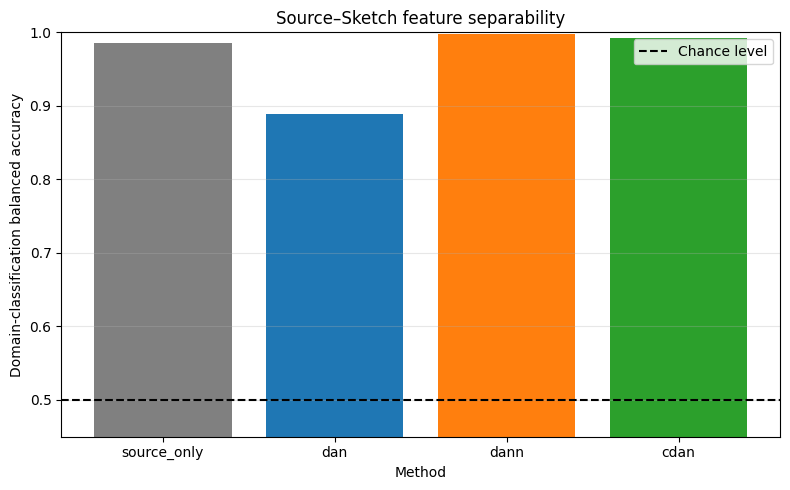

Figure saved to: /content/drive/MyDrive/ATML/PA1-repo/task2/figures/domain_separability.png


In [17]:
ordered_diagnostic = (
    domain_diagnostic_table
    .set_index("method")
    .loc[method_order]
    .reset_index()
)

figure, axis = plt.subplots(
    figsize=(8, 5),
)

axis.bar(
    ordered_diagnostic["method"],
    ordered_diagnostic[
        "domain_balanced_accuracy"
    ],
    color=[
        "gray",
        "tab:blue",
        "tab:orange",
        "tab:green",
    ],
)

axis.axhline(
    0.5,
    color="black",
    linestyle="--",
    label="Chance level",
)

axis.set_ylim(0.45, 1.0)
axis.set_xlabel("Method")
axis.set_ylabel(
    "Domain-classification "
    "balanced accuracy"
)
axis.set_title(
    "Source–Sketch feature separability"
)
axis.grid(
    axis="y",
    alpha=0.3,
)
axis.legend()

figure.tight_layout()

figure_path = (
    TASK2_REPO_ROOT
    / "figures/"
    "domain_separability.png"
)

figure.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to:",
    figure_path,
)

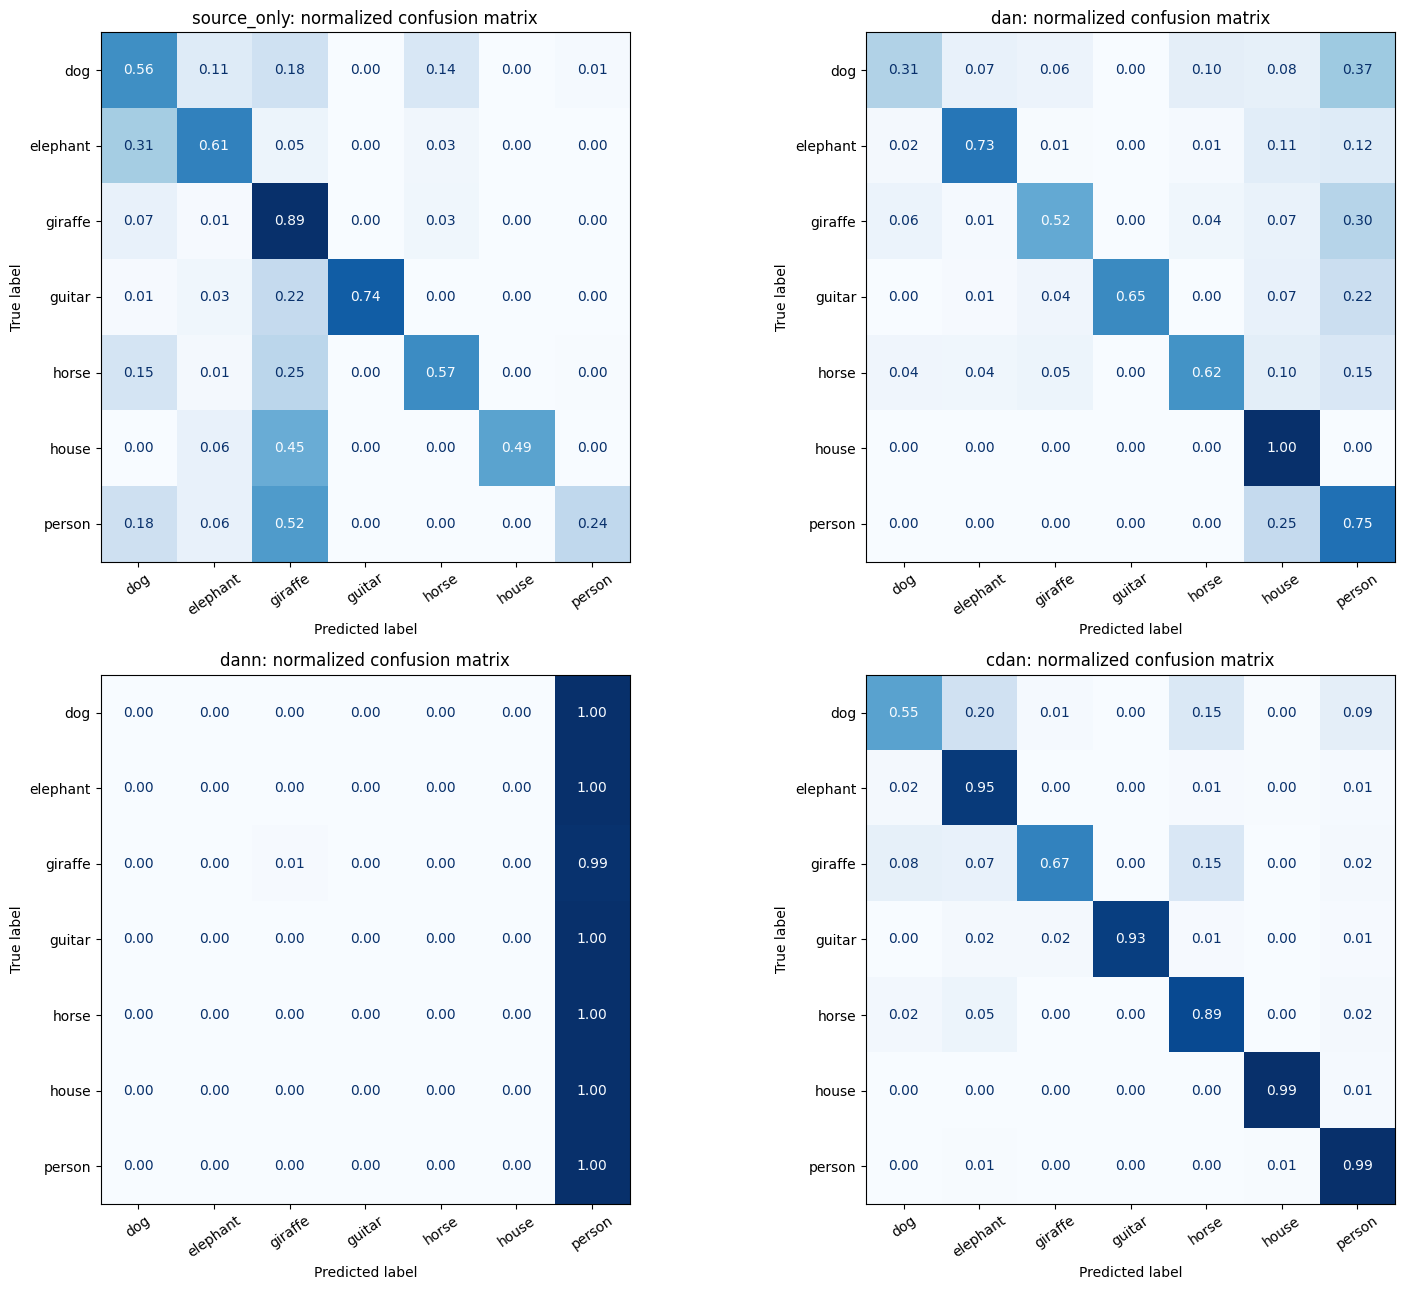

Figure saved to: /content/drive/MyDrive/ATML/PA1-repo/task2/figures/target_sketch_confusion_matrices.png


In [18]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
)


figure, axes = plt.subplots(
    2,
    2,
    figsize=(16, 13),
)

for axis, method_name in zip(
    axes.ravel(),
    method_order,
):
    output = target_outputs[
        method_name
    ]

    ConfusionMatrixDisplay.from_predictions(
        output["true_labels"],
        output["predicted_labels"],
        labels=range(
            len(CLASS_NAMES)
        ),
        display_labels=CLASS_NAMES,
        normalize="true",
        values_format=".2f",
        cmap="Blues",
        colorbar=False,
        ax=axis,
    )

    axis.set_title(
        f"{method_name}: normalized confusion matrix"
    )

    axis.tick_params(
        axis="x",
        rotation=35,
    )

figure.tight_layout()

confusion_figure_path = (
    TASK2_REPO_ROOT
    / "figures/"
    "target_sketch_confusion_matrices.png"
)

figure.savefig(
    confusion_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to:",
    confusion_figure_path,
)

In [19]:
import json


final_evaluation_metadata = {
    "target_domain": "sketch",
    "number_of_target_samples": int(
        len(target_evaluation_dataset)
    ),
    "class_names": CLASS_NAMES,
    "checkpoint_selection": (
        "mean source-validation macro-F1"
    ),
    "target_evaluated_after_selection": True,
    "target_labels_used_for_training": False,
    "target_labels_used_for_tuning": False,
    "dan_selected_mmd_weight": 1.0,
    "dann_maximum_grl_strength": 0.1,
    "cdan_maximum_grl_strength": 0.1,
    "target_results": [
        {
            "method": row["method"],
            "selected_epoch": int(
                row["selected_epoch"]
            ),
            "source_selection_macro_f1": (
                float(
                    row[
                        "source_selection_macro_f1"
                    ]
                )
            ),
            "target_accuracy": float(
                row["target_accuracy"]
            ),
            "target_macro_f1": float(
                row["target_macro_f1"]
            ),
        }
        for row in target_summary.to_dict(
            orient="records"
        )
    ],
    "domain_separability": [
        {
            "method": row["method"],
            "domain_accuracy": float(
                row["domain_accuracy"]
            ),
            "domain_balanced_accuracy": (
                float(
                    row[
                        "domain_balanced_accuracy"
                    ]
                )
            ),
            "domain_roc_auc": float(
                row["domain_roc_auc"]
            ),
        }
        for row in (
            domain_diagnostic_table
            .to_dict(
                orient="records"
            )
        )
    ],
}

metadata_path = (
    TASK2_REPO_ROOT
    / "results/"
    "final_evaluation_metadata.json"
)

with metadata_path.open(
    "w",
    encoding="utf-8",
) as metadata_file:
    json.dump(
        final_evaluation_metadata,
        metadata_file,
        indent=2,
    )

print(
    json.dumps(
        final_evaluation_metadata,
        indent=2,
    )
)

print()
print(
    "Metadata saved to:",
    metadata_path,
)

{
  "target_domain": "sketch",
  "number_of_target_samples": 3929,
  "class_names": [
    "dog",
    "elephant",
    "giraffe",
    "guitar",
    "horse",
    "house",
    "person"
  ],
  "checkpoint_selection": "mean source-validation macro-F1",
  "target_evaluated_after_selection": true,
  "target_labels_used_for_training": false,
  "target_labels_used_for_tuning": false,
  "dan_selected_mmd_weight": 1.0,
  "dann_maximum_grl_strength": 0.1,
  "cdan_maximum_grl_strength": 0.1,
  "target_results": [
    {
      "method": "cdan",
      "selected_epoch": 11,
      "source_selection_macro_f1": 0.935145377706295,
      "target_accuracy": 0.804530414863833,
      "target_macro_f1": 0.8118815736716278
    },
    {
      "method": "source_only",
      "selected_epoch": 12,
      "source_selection_macro_f1": 0.9366743407680399,
      "target_accuracy": 0.6482565538304912,
      "target_macro_f1": 0.6240024389156957
    },
    {
      "method": "dan",
      "selected_epoch": 7,
      "source_se